# Module 10 — Multiple Regression

**Statistics Deep Dive · Notebook 10 of 13**

One predictor is rarely enough. Multiple regression lets us (1) **predict** better by using several variables, and (2) **adjust**: estimate the association of one variable with the outcome *while holding the others constant* — the closest observational data gets to "all else being equal". Both uses come with traps, and this module walks through them.

### 🎯 Learning goals
After this module you can …
1. interpret coefficients as **partial effects** and explain **omitted-variable bias**,
2. use **categorical predictors** and **interactions** and read their coefficients correctly,
3. compare models with **adjusted $R^2$, nested $F$-tests and AIC/BIC**,
4. diagnose **multicollinearity** (VIF), **influential points** and **heteroscedasticity** (robust standard errors),
5. recognise **overfitting**, estimate out-of-sample error by **cross-validation**,
6. apply **ridge** and **lasso** regularisation.

### 🗺️ Contents
1. The model · 2. Why coefficients change: omitted-variable bias · 3. Categorical predictors & interactions · 4. Comparing models · 5. Multicollinearity · 6. Influential points & unequal variance · 7. Overfitting & cross-validation · 8. Ridge & lasso · 9. Exercises · 10. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split

---
## 1. The model — from a line to a (hyper)plane

$$y_i=\beta_0+\beta_1x_{i1}+\beta_2x_{i2}+\dots+\beta_px_{ip}+\varepsilon_i \qquad\Longleftrightarrow\qquad \mathbf y=\mathbf X\boldsymbol\beta+\boldsymbol\varepsilon,\qquad \hat{\boldsymbol\beta}=(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y$$

Least squares works exactly as before — with two predictors we fit a **plane** instead of a line. The crucial change is the **interpretation**:

> $\beta_j$ is the expected change in $y$ for a one-unit increase in $x_j$ **with all other predictors in the model held constant**.

It is a *partial* effect, and it depends on *which* other predictors are in the model.

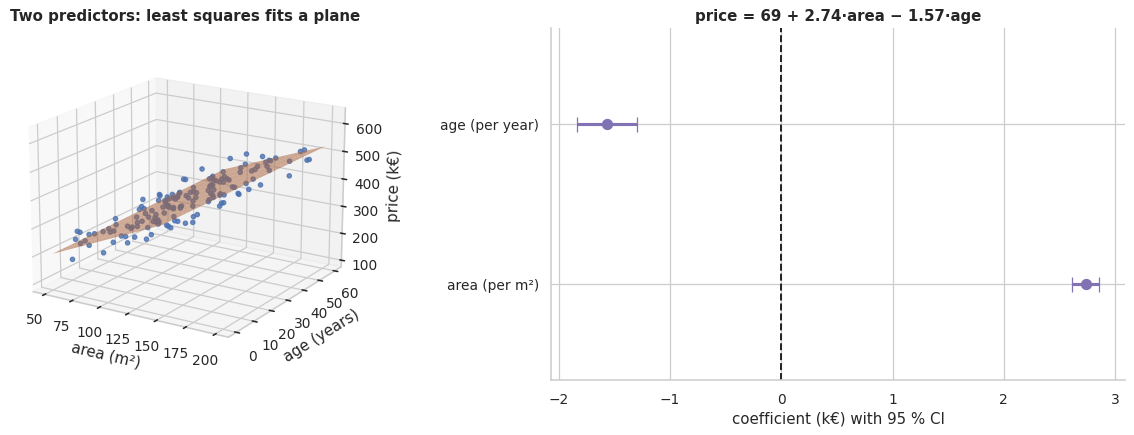

In [2]:
n = 150
houses = pd.DataFrame({"area": rng.uniform(50, 200, n), "age": rng.uniform(0, 60, n)})
houses["price"] = 60 + 2.8 * houses.area - 1.5 * houses.age + rng.normal(0, 30, n)             # k€
m = smf.ols("price ~ area + age", data=houses).fit()

fig = plt.figure(figsize=(14, 5)); ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(houses.area, houses.age, houses.price, color=C[0], s=12, alpha=.8)
A, G = np.meshgrid(np.linspace(50, 200, 12), np.linspace(0, 60, 12))
ax.plot_surface(A, G, m.params["Intercept"] + m.params["area"] * A + m.params["age"] * G, color=C[1], alpha=.55, linewidth=0)
ax.set(xlabel="area (m²)", ylabel="age (years)", zlabel="price (k€)", title="Two predictors: least squares fits a plane"); ax.view_init(18, -58)
ax2 = fig.add_subplot(1, 2, 2); ci = m.conf_int().drop("Intercept")
ax2.errorbar(m.params.drop("Intercept"), range(2), xerr=[m.params.drop("Intercept") - ci[0], ci[1] - m.params.drop("Intercept")], fmt="o", color=C[4], capsize=6, lw=2.5, ms=8)
ax2.axvline(0, color="k", ls="--"); ax2.set(yticks=range(2), yticklabels=["area (per m²)", "age (per year)"], ylim=(-.6, 1.6), xlabel="coefficient (k€) with 95 % CI",
                                            title=f"price = {m.params['Intercept']:.0f} + {m.params['area']:.2f}·area − {abs(m.params['age']):.2f}·age")
plt.tight_layout(); plt.show()

---
## 2. Why coefficients change — omitted-variable bias

> 🤔 **Predict first:** does an extra bedroom raise the price of a house? What if the living area stays the same?

Bedrooms and area are strongly correlated (bigger houses have more bedrooms). If area is **omitted**, the bedroom coefficient absorbs the effect of area. In general, omitting $x_2$ from the model gives

$$\tilde\beta_1=\beta_1+\beta_2\,\delta,\qquad \delta=\text{slope of } x_2 \text{ regressed on } x_1 .$$

The bias is large when the omitted variable matters ($\beta_2$) **and** is correlated with the included one ($\delta$). It can even flip the sign.

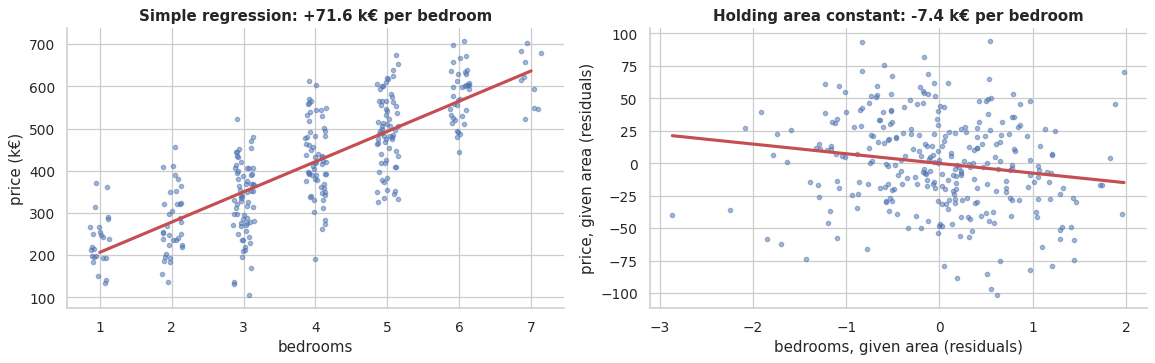

In [3]:
n = 300
area = rng.uniform(50, 220, n)
bedrooms = np.clip(np.round(area / 35 + rng.normal(0, .8, n)), 1, 7)
price = 40 + 3.0 * area - 8 * bedrooms + rng.normal(0, 35, n)          # for a GIVEN area, more (= smaller) rooms lower the price
d = pd.DataFrame({"area": area, "bedrooms": bedrooms, "price": price})
simple, full = smf.ols("price ~ bedrooms", d).fit(), smf.ols("price ~ bedrooms + area", d).fit()

res_price = smf.ols("price ~ area", d).fit().resid; res_bed = smf.ols("bedrooms ~ area", d).fit().resid       # 'area removed' from both
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
a1.scatter(d.bedrooms + rng.uniform(-.15, .15, n), d.price, s=12, alpha=.5, color=C[0]); xx = np.array([1, 7]); a1.plot(xx, simple.params["Intercept"] + simple.params["bedrooms"] * xx, color=C[3], lw=2.5)
a1.set(xlabel="bedrooms", ylabel="price (k€)", title=f"Simple regression: {simple.params['bedrooms']:+.1f} k€ per bedroom")
a2.scatter(res_bed, res_price, s=12, alpha=.5, color=C[0]); xx = np.array([res_bed.min(), res_bed.max()]); a2.plot(xx, full.params["bedrooms"] * xx, color=C[3], lw=2.5)
a2.set(xlabel="bedrooms, given area (residuals)", ylabel="price, given area (residuals)", title=f"Holding area constant: {full.params['bedrooms']:+.1f} k€ per bedroom")
plt.tight_layout(); plt.show()

**Reading the figure.** *Left:* across all houses, each bedroom "adds" tens of thousands of euros — because bedrooms are a proxy for size. *Right:* the **added-variable plot** shows what multiple regression really does: it removes area from both price and bedrooms, then regresses the leftovers on each other. Among houses of the *same* size, an extra bedroom means smaller rooms — and a slightly **lower** price. Neither number is "wrong": they answer different questions. Be clear which one you are asking.

> ⚠️ Adjustment is not magic. Controlling for a **confounder** removes bias. Controlling for a **mediator** (a variable on the causal path) removes part of the effect you want to measure; controlling for a **collider** (a common *consequence*) creates bias that was not there. Which is which is a subject-matter question, not a statistical one.

---
## 3. Categorical predictors & interactions

A categorical variable with $k$ levels enters the model as $k-1$ **dummy (indicator) variables**; the omitted level is the **reference**, and each dummy coefficient is the difference to that reference. *statsmodels* does this automatically for text columns.

An **interaction** lets the slope of one predictor depend on another predictor (compare the two-way ANOVA in Module 7):

$$\text{salary}=\beta_0+\beta_1\,\text{exper}+\beta_2\,\text{Master}+\beta_3\,(\text{exper}\times\text{Master})+\varepsilon$$

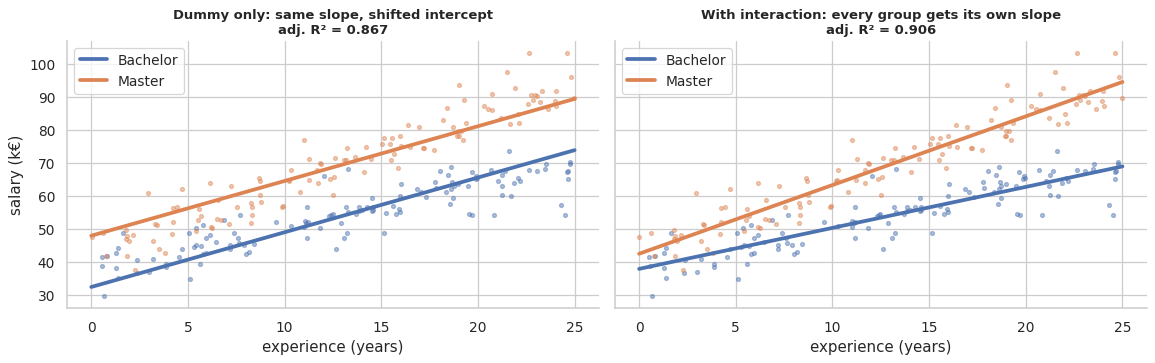

                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 37.9729      0.881     43.092      0.000      36.237      39.709
degree[T.Master]           4.5843      1.245      3.683      0.000       2.132       7.036
exper                      1.2415      0.059     21.042      0.000       1.125       1.358
exper:degree[T.Master]     0.8397      0.084     10.021      0.000       0.675       1.005


In [4]:
n = 240
sal = pd.DataFrame({"exper": rng.uniform(0, 25, n), "degree": rng.choice(["Bachelor", "Master"], n)})
sal["salary"] = 38 + 1.2 * sal.exper + np.where(sal.degree == "Master", 6 + .8 * sal.exper, 0) + rng.normal(0, 5, n)      # k€
m_par = smf.ols("salary ~ exper + degree", data=sal).fit()              # parallel lines
m_int = smf.ols("salary ~ exper * degree", data=sal).fit()              # '*' = both main effects + interaction

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
grid = pd.DataFrame({"exper": np.tile([0, 25], 2), "degree": np.repeat(["Bachelor", "Master"], 2)})
for ax, mod, title in zip(axes, [m_par, m_int], ["Dummy only: same slope, shifted intercept", "With interaction: every group gets its own slope"]):
    for deg, col in zip(["Bachelor", "Master"], [C[0], C[1]]):
        s = sal[sal.degree == deg]; ax.scatter(s.exper, s.salary, s=10, alpha=.45, color=col)
        gsub = grid[grid.degree == deg]; ax.plot(gsub.exper, mod.predict(gsub), color=col, lw=3, label=deg)
    ax.set(xlabel="experience (years)", title=f"{title}\nadj. R² = {mod.rsquared_adj:.3f}"); ax.title.set_fontsize(10.5); ax.legend()
axes[0].set_ylabel("salary (k€)"); plt.tight_layout(); plt.show()
print(m_int.summary().tables[1])

**Reading the coefficients of the interaction model**

| Coefficient | Meaning |
|---|---|
| `Intercept` | expected salary of the **reference group** (Bachelor) at 0 years |
| `exper` | slope **for the reference group**: +1.2 k€ per year for Bachelors |
| `degree[T.Master]` | Master − Bachelor gap **at exper = 0** (not "the" Master effect!) |
| `exper:degree[T.Master]` | **extra** slope for Masters: their salary grows ≈ 0.8 k€/year faster |

With an interaction in the model, a main effect is the effect *where the other variable equals zero*. Centre numeric predictors if you want main effects "at the average".

---
## 4. Comparing models

Adding predictors can only increase $R^2$ — even pure noise does. Fair comparisons penalise complexity:

| Tool | Idea | Use |
|---|---|---|
| **Adjusted $R^2$** | $1-\frac{SSE/(n-p-1)}{SST/(n-1)}$ | quick check; rises only if the new predictor helps more than chance would |
| **Nested $F$-test** | does the bigger model reduce SSE significantly? | models where one is a special case of the other |
| **AIC / BIC** | $-2\ell+2k$ / $-2\ell+k\ln n$ — fit plus penalty, *lower is better* | any models fitted to the same data; BIC prefers smaller models |
| **Cross-validation** | measure prediction error on held-out data (section 7) | the honest tool when prediction is the goal |

In [5]:
m0 = smf.ols("salary ~ exper", data=sal).fit()
print(pd.DataFrame({name: {"R²": mod.rsquared, "adj. R²": mod.rsquared_adj, "AIC": mod.aic, "BIC": mod.bic}
                    for name, mod in [("exper", m0), ("exper + degree", m_par), ("exper * degree", m_int)]}).T.round(3))
print("\nNested F-tests:"); print(sm.stats.anova_lm(m0, m_par, m_int).round(4))

                   R²  adj. R²       AIC       BIC
exper           0.600    0.598  1765.143  1772.104
exper + degree  0.868    0.867  1501.073  1511.515
exper * degree  0.907    0.906  1417.990  1431.912

Nested F-tests:
   df_resid         ssr  df_diff     ss_diff         F  Pr(>F)
0     238.0  21608.8358      0.0         NaN       NaN     NaN
1     237.0   7131.1971      1.0  14477.6387  682.9855     0.0
2     236.0   5002.6285      1.0   2128.5686  100.4156     0.0


---
## 5. Multicollinearity — when predictors tell the same story

If two predictors are highly correlated, the data cannot tell their effects apart: many different coefficient pairs fit almost equally well. The model still **predicts** fine, but individual coefficients become unstable — huge standard errors, implausible signs, large changes when a few rows are added.

**Variance inflation factor:** $\;VIF_j=\dfrac{1}{1-R_j^2}$, where $R_j^2$ comes from regressing $x_j$ on all other predictors. It is the factor by which $\operatorname{Var}(\hat\beta_j)$ is inflated compared with uncorrelated predictors. Rules of thumb: VIF > 5 worth a look, > 10 serious.

**Simulation:** true model $y=1\cdot x_1+1\cdot x_2+\varepsilon$; we refit on 1,500 fresh samples.

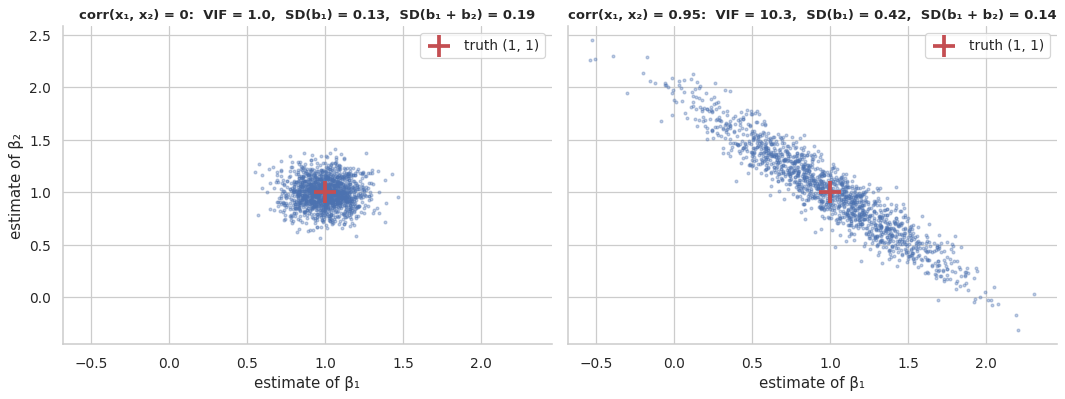

In [6]:
def simulate_coefs(rho, R=1500, n=60):
    out = np.empty((R, 2))
    for i in range(R):
        X = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n); y = X[:, 0] + X[:, 1] + rng.normal(0, 1, n)
        out[i] = np.linalg.lstsq(np.column_stack([np.ones(n), X]), y, rcond=None)[0][1:]
    return out

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, rho in zip(axes, [0, .95]):
    b = simulate_coefs(rho)
    ax.scatter(b[:, 0], b[:, 1], s=5, alpha=.35, color=C[0]); ax.scatter(1, 1, marker="+", s=300, color=C[3], lw=3, zorder=3, label="truth (1, 1)")
    ax.set(xlabel="estimate of β₁", title=f"corr(x₁, x₂) = {rho}:  VIF = {1 / (1 - rho ** 2):.1f},  SD(b₁) = {b[:, 0].std():.2f},  SD(b₁ + b₂) = {b.sum(axis=1).std():.2f}"); ax.title.set_fontsize(10.5); ax.legend()
axes[0].set_ylabel("estimate of β₂"); plt.tight_layout(); plt.show()

**Reading the figure.** With correlated predictors the estimates scatter along a diagonal: if $b_1$ is too high, $b_2$ is too low by the same amount. The **sum** $b_1+b_2$ (the effect of raising both together) is estimated as precisely as before — only the *split* is uncertain.

**What to do?** Nothing, if you only care about prediction or about other coefficients. Otherwise: collect data in which the predictors vary independently (an experiment!), combine them into one index, drop one (and interpret accordingly), or use ridge regression (section 8).

---
## 6. Influential points & unequal variance

**Leverage** measures how unusual an observation's *predictor values* are; an observation is **influential** if deleting it changes the fit noticeably — that takes high leverage *and* a large residual. **Cook's distance** combines both (values above ≈ $4/n$, and certainly above 1, deserve a look).

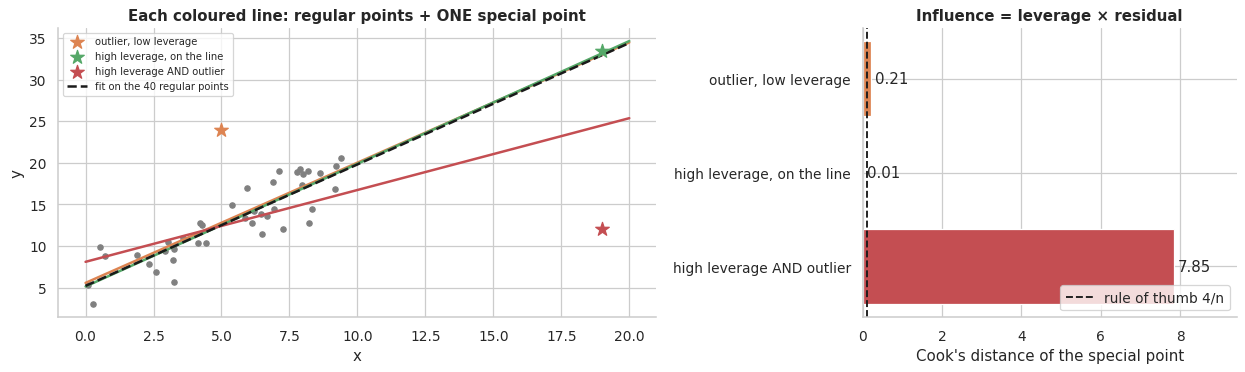

In [7]:
x = rng.uniform(0, 10, 40); y = 5 + 1.5 * x + rng.normal(0, 2, 40)
d = pd.DataFrame({"x": np.append(x, [5, 19, 19]), "y": np.append(y, [24, 33.5, 12]), "kind": ["regular"] * 40 + ["outlier, low leverage", "high leverage, on the line", "high leverage AND outlier"]})
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.6, 1]})
a1.scatter(d.x[:40], d.y[:40], s=18, color="grey"); xx = np.array([0, 20]); cooks = {}
for i, col in zip([40, 41, 42], [C[1], C[2], C[3]]):
    mi = smf.ols("y ~ x", d.drop(index=[j for j in [40, 41, 42] if j != i])).fit()            # 40 regular points + ONE special point (last row)
    cooks[d.kind[i]] = mi.get_influence().cooks_distance[0][-1]
    a1.scatter(d.x[i], d.y[i], s=130, color=col, marker="*", zorder=3, label=d.kind[i]); a1.plot(xx, mi.params["Intercept"] + mi.params["x"] * xx, color=col, lw=2)
m40 = smf.ols("y ~ x", d.iloc[:40]).fit(); a1.plot(xx, m40.params["Intercept"] + m40.params["x"] * xx, "k--", lw=2, label="fit on the 40 regular points")
a1.set(title="Each coloured line: regular points + ONE special point", xlabel="x", ylabel="y"); a1.legend(fontsize=8)
bars = a2.barh(list(cooks), list(cooks.values()), color=[C[1], C[2], C[3]]); a2.bar_label(bars, fmt="%.2f", padding=3); a2.axvline(4 / 41, color="k", ls="--", label="rule of thumb 4/n")
a2.set(xlabel="Cook's distance of the special point", title="Influence = leverage × residual", xlim=(0, max(cooks.values()) * 1.2)); a2.invert_yaxis(); a2.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Reading the figure.** The orange point is a gross outlier but sits in the middle of the $x$-range: it shifts the line a little, it cannot tilt it. The green point is extreme in $x$ but consistent with the trend — harmless (it even *improves* precision). Only the red point — extreme in $x$ **and** off the trend — drags the line towards itself. Never delete such points automatically: check for data errors, then report results with and without them.

### 6.1 Heteroscedasticity and robust standard errors
If the error variance is not constant, OLS coefficients remain unbiased but the usual standard errors are **wrong**. Detection: residual plot, **Breusch–Pagan test**. Remedies: transform $y$ (Module 9), or keep the model and use **heteroscedasticity-consistent ("robust", HC3) standard errors**.

In [8]:
n = 400; x = rng.uniform(1, 10, n)
het = pd.DataFrame({"x": x, "y": 10 + 3 * x + rng.normal(0, .3 + .25 * x ** 1.5, n)})             # noise grows with x
m = smf.ols("y ~ x", het).fit(); m_rob = m.get_robustcov_results(cov_type="HC3")
print(f"Breusch–Pagan test: p = {het_breuschpagan(m.resid, m.model.exog)[1]:.2e}  (H0: constant variance)")
print(pd.DataFrame({"coef": m.params, "classical SE": m.bse, "robust SE (HC3)": m_rob.bse}, index=m.params.index).round(4))

Breusch–Pagan test: p = 1.14e-11  (H0: constant variance)
             coef  classical SE  robust SE (HC3)
Intercept  9.8808        0.5195           0.4019
x          3.0635        0.0857           0.0988


---
## 7. Overfitting & cross-validation

A model with enough parameters can fit *anything* — including the noise. Such a model looks great on the data it was trained on and fails on new data. The only honest measure of predictive quality is the error on data **not used for fitting**.

**$k$-fold cross-validation:** split the data into $k$ parts; fit on $k-1$ parts, predict the held-out part; rotate; average the $k$ errors. Every observation serves once as test data.

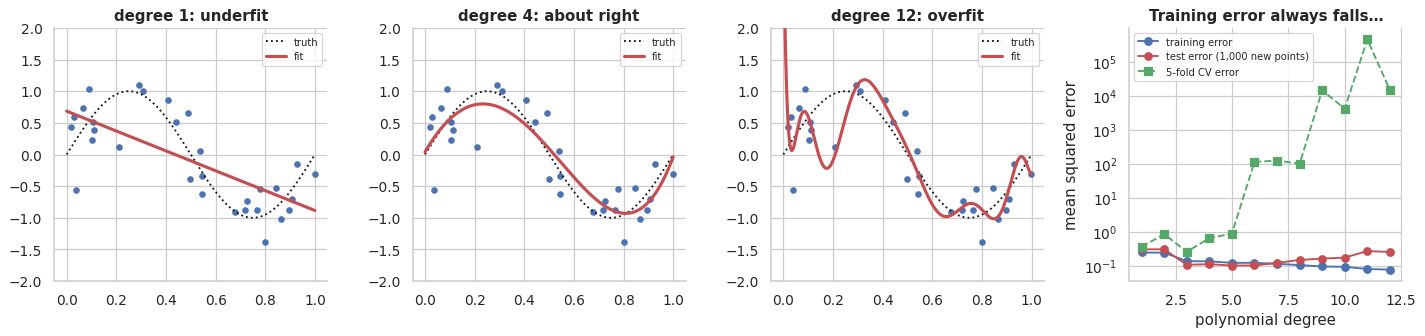

In [9]:
f = lambda x: np.sin(2 * np.pi * x)
x_tr = np.sort(rng.uniform(0, 1, 30)); y_tr = f(x_tr) + rng.normal(0, .3, 30)
x_te = rng.uniform(0, 1, 1000); y_te = f(x_te) + rng.normal(0, .3, 1000)
degrees = np.arange(1, 13); train_err, test_err, cv_err = [], [], []
for dgr in degrees:
    pipe = make_pipeline(PolynomialFeatures(dgr), LinearRegression()).fit(x_tr[:, None], y_tr)
    train_err.append(np.mean((pipe.predict(x_tr[:, None]) - y_tr) ** 2)); test_err.append(np.mean((pipe.predict(x_te[:, None]) - y_te) ** 2))
    cv_err.append(-cross_val_score(pipe, x_tr[:, None], y_tr, cv=5, scoring="neg_mean_squared_error").mean())

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9)); xx = np.linspace(0, 1, 300)
for ax, dgr, name in zip(axes[:3], [1, 4, 12], ["underfit", "about right", "overfit"]):
    pipe = make_pipeline(PolynomialFeatures(dgr), LinearRegression()).fit(x_tr[:, None], y_tr)
    ax.scatter(x_tr, y_tr, s=18, color=C[0]); ax.plot(xx, f(xx), "k:", label="truth"); ax.plot(xx, pipe.predict(xx[:, None]), color=C[3], lw=2.5, label="fit")
    ax.set(ylim=(-2, 2), title=f"degree {dgr}: {name}"); ax.legend(fontsize=8)
axes[3].plot(degrees, train_err, "o-", color=C[0], label="training error"); axes[3].plot(degrees, test_err, "o-", color=C[3], label="test error (1,000 new points)"); axes[3].plot(degrees, cv_err, "s--", color=C[2], label="5-fold CV error")
axes[3].set(yscale="log", xlabel="polynomial degree", ylabel="mean squared error", title="Training error always falls…"); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the figure.** Training error decreases monotonically with complexity — it is useless for model choice. Test error is **U-shaped**: too simple → *bias* (underfit), too flexible → *variance* (overfit) — the bias–variance trade-off of Module 5 again. Cross-validation (green), computed from the 30 training points alone, tracks the test error well enough to find the right complexity.

---
## 8. Regularisation — ridge & lasso

Instead of choosing *which* predictors to include, **shrink all coefficients** towards zero by adding a penalty to the least-squares criterion:

$$\text{Ridge:}\ \min_\beta \sum(y_i-\hat y_i)^2+\lambda\sum_j\beta_j^2 \qquad\qquad \text{Lasso:}\ \min_\beta\sum(y_i-\hat y_i)^2+\lambda\sum_j\lvert\beta_j\rvert$$

* **Ridge** ($L_2$) shrinks smoothly, never exactly to zero; it shares weight among correlated predictors → the cure for multicollinearity.
* **Lasso** ($L_1$) sets some coefficients **exactly to zero** → automatic variable selection, sparse models.
* $\lambda$ (called `alpha` in scikit-learn) controls the strength and is chosen by **cross-validation**. Predictors must be **standardised** first, otherwise the penalty depends on their units.

We trade a little bias for a big reduction in variance. **Real data:** disease progression of 442 diabetes patients one year after baseline, 10 baseline predictors (Efron et al., 2004).

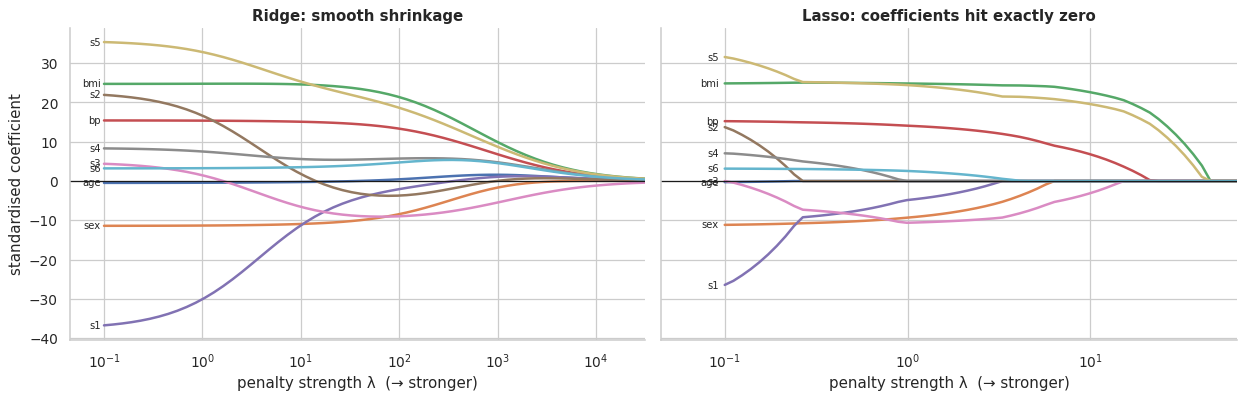

In [10]:
diab = load_diabetes(as_frame=True); X = StandardScaler().fit_transform(diab.data); y = diab.target; names = diab.data.columns
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, Model, alphas, title in [(axes[0], Ridge, np.logspace(-1, 4.5, 60), "Ridge: smooth shrinkage"), (axes[1], Lasso, np.logspace(-1, 1.8, 60), "Lasso: coefficients hit exactly zero")]:
    paths = np.array([Model(alpha=a, max_iter=50_000).fit(X, y).coef_ for a in alphas])
    for j, name in enumerate(names):
        ax.plot(alphas, paths[:, j], lw=2); ax.text(alphas[0] * .93, paths[0, j], name, ha="right", va="center", fontsize=8)
    ax.axhline(0, color="k", lw=1); ax.set(xscale="log", xlabel="penalty strength λ  (→ stronger)", title=title, xlim=(alphas[0] * .45, alphas[-1]))
axes[0].set_ylabel("standardised coefficient"); plt.tight_layout(); plt.show()

**Reading the figure.** Moving right, the penalty grows. Ridge pulls all coefficients gradually towards zero; note how the two strongly correlated blood-serum measurements `s1` and `s2` (huge, opposite-signed OLS coefficients on the far left — a multicollinearity symptom) are tamed quickly. Under the lasso, predictors drop out one after another; `bmi`, `s5` (a lipid measure) and `bp` (blood pressure) survive longest — the most robust predictors.

> ⚠️ After data-driven selection (lasso, stepwise …) the usual p-values and CIs of the selected model are **invalid** — the same data were used to choose *and* to test. Regularised models are prediction tools; for inference use a pre-specified model or sample splitting.

---
## 9. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 10.1 — *Partial effects & omitted-variable bias*: What drives house prices? (Real-estate valuation)

A valuation firm has data on 400 sold houses: living area, number of bedrooms, age, distance to the city centre and whether there is a garage.

**Tasks**
1. Regress price on bedrooms alone. Then fit the full model. Compare the bedroom coefficients and explain the difference.
2. Interpret every coefficient of the full model in one sentence, with its 95 % CI.
3. Which predictor matters most? Refit with **standardised** numeric predictors (z-scores) to compare.
4. Predict the price (with 95 % prediction interval) of a 140 m², 4-bedroom, 25-year-old house, 6 km from the centre, with garage.

In [11]:
g = np.random.default_rng(1001)
n = 400
area = g.uniform(60, 240, n)
hp = pd.DataFrame({"area": area.round(0), "bedrooms": np.clip(np.round(area / 38 + g.normal(0, .7, n)), 1, 7), "age": g.uniform(0, 80, n).round(0),
                   "dist_km": g.gamma(2, 4, n).round(1), "garage": np.where(g.random(n) < .2 + .002 * area, "yes", "no")})
hp["price"] = (120 + 2.9 * hp.area - 9 * hp.bedrooms - .9 * hp.age - 6.5 * hp.dist_km + 25 * (hp.garage == "yes") + g.normal(0, 38, n)).round(0)      # k€
hp.head()

,area,bedrooms,age,dist_km,garage,price
0,170.0,4.0,15.0,3.4,yes,598.0
1,63.0,2.0,52.0,12.7,no,130.0
2,94.0,2.0,69.0,5.5,no,231.0
3,214.0,5.0,34.0,21.0,no,527.0
4,74.0,1.0,42.0,6.0,no,201.0


In [12]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/10_multiple_regression_solutions.ipynb`.

### ✍️ Exercise 10.2 — *Dummy variables, adjustment & interactions*: A pay-gap audit (HR analytics)

The works council asks for an audit of the gender pay gap among 600 employees. You have salary, gender, job level and years of experience.

**Tasks**
1. Compute the **raw** pay gap (regression of salary on gender).
2. Compute the **adjusted** gap, controlling for job level and experience. Why does it differ?
3. Test whether the gap differs between job levels (interaction gender × level; nested $F$-test).
4. How are men and women distributed over the job levels? Which of the two gaps is "the" pay gap? What can the adjusted analysis *not* tell you?

In [13]:
g = np.random.default_rng(1013)
n = 600; levels = ["junior", "senior", "manager"]
gender = g.choice(["female", "male"], n, p=[.45, .55])
level = np.where(gender == "male", g.choice(levels, n, p=[.35, .40, .25]), g.choice(levels, n, p=[.50, .38, .12]))
exper = np.clip(pd.Series(level).map({"junior": 3, "senior": 10, "manager": 17}).values + g.normal(0, 3, n), 0, None).round(1)
salary = 42 + pd.Series(level).map({"junior": 0, "senior": 14, "manager": 32}).values + .9 * exper - 1.8 * (gender == "female") + g.normal(0, 6, n)
pay = pd.DataFrame({"gender": gender, "level": pd.Categorical(level, categories=levels), "exper": exper, "salary": salary.round(1)})
pay.groupby("gender").salary.agg(["count", "mean"]).round(1)

,count,mean
gender,,
female,273,57.6
male,327,64.8


In [14]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/10_multiple_regression_solutions.ipynb`.

### ✍️ Exercise 10.3 — *Multicollinearity*: Which advertising channel works? (Marketing-mix modelling)

Two years of weekly data: spend on TV, online and social media (k€), a price index, and sales. Management wants to know the return of each channel. Problem: the marketing department always scales all channels up and down *together*.

**Tasks**
1. Inspect the correlation matrix of the predictors.
2. Fit the full model. Compare the overall $F$-test / $R^2$ with the individual coefficient tests. What is odd?
3. Compute the VIFs.
4. Fit a model with **total spend** instead of the three channels. What can you conclude from these data — and what not? How could the company find out?

In [15]:
g = np.random.default_rng(1003)
n = 104; budget = g.gamma(6, 10, n)
mix = pd.DataFrame({"tv": budget * .5 + g.normal(0, 3, n), "online": budget * .3 + g.normal(0, 2, n), "social": budget * .2 + g.normal(0, 1.5, n), "price_idx": g.normal(100, 5, n)}).round(1)
mix["sales"] = (200 + 1.8 * mix.tv + 3.0 * mix.online + 1.0 * mix.social - 1.5 * (mix.price_idx - 100) + g.normal(0, 25, n)).round(0)
mix.corr().round(2)

,tv,online,social,price_idx,sales
tv,1.00,0.91,0.92,-0.08,0.86
online,0.91,1.00,0.92,-0.00,0.81
social,0.92,0.92,1.00,-0.03,0.82
price_idx,-0.08,-0.00,-0.03,1.00,-0.14
sales,0.86,0.81,0.82,-0.14,1.00


In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/10_multiple_regression_solutions.ipynb`.

### ✍️ Exercise 10.4 — *Heteroscedasticity, log-transformation & interaction*: Modelling medical insurance charges (Actuarial pricing)

A health insurer models annual medical charges from age, BMI and smoking status.

**Tasks**
1. Fit `charges ~ age + bmi + smoker`. Plot residuals vs. fitted values and run the Breusch–Pagan test.
2. Fit the same model for `np.log(charges)`. Check the residuals again.
3. Add the interaction `bmi * smoker` to the log model. Is it needed (nested $F$-test, AIC)?
4. Interpret the coefficients of the final model as **percentage effects**. What does the interaction mean in plain language?

In [17]:
g = np.random.default_rng(1004)
n = 800
ins = pd.DataFrame({"age": g.integers(18, 65, n), "bmi": g.normal(28, 5, n).clip(16, 48).round(1), "smoker": np.where(g.random(n) < .2, "yes", "no")})
ins["charges"] = np.exp(7.6 + .033 * ins.age + .012 * (ins.bmi - 28) + (1.0 + .045 * (ins.bmi - 28)) * (ins.smoker == "yes") + g.normal(0, .35, n)).round(0)
ins.groupby("smoker").charges.describe().round(0)

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,651.0,9254.0,5458.0,1314.0,5135.0,7826.0,11921.0,30726.0
yes,149.0,26657.0,19743.0,4828.0,14024.0,20916.0,33608.0,120689.0


In [18]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/10_multiple_regression_solutions.ipynb`.

### ✍️ Exercise 10.5 — *Overfitting & regularisation*: Predicting diabetes progression (Medical prognosis, real data)

Using the diabetes data from section 8, a researcher wants to allow for non-linearities and interactions and expands the 10 predictors to all squares and pairwise products — **65 features** for a few hundred patients.

**Tasks**
1. Split the data (75 % training, 25 % test). Compare three pipelines on the expanded features: plain OLS, `RidgeCV`, `LassoCV` (always standardise first). Report training and test RMSE.
2. For reference: test RMSE of plain OLS on the original 10 features.
3. How many of the 65 features does the lasso keep? Which have the largest coefficients?
4. What do you conclude about flexible models, and why must the test set stay untouched until the end?

In [19]:
diab = load_diabetes(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(diab.data, diab.target, test_size=.25, random_state=0)
expand = lambda: PolynomialFeatures(degree=2, include_bias=False)
print(X_train.shape, "->", expand().fit_transform(X_train).shape)

(331, 10) -> (331, 65)


In [20]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/10_multiple_regression_solutions.ipynb`.

---
## 10. 🔑 Key takeaways

* A multiple-regression coefficient is a **partial effect** — "holding the other predictors constant" — and it changes when the set of other predictors changes (**omitted-variable bias**).
* Adjust for **confounders**; do not blindly adjust for mediators or colliders. Statistics cannot tell you which is which.
* **Dummies** shift intercepts, **interactions** change slopes; with an interaction, main effects refer to the zero point of the other variable.
* Compare models with adjusted $R^2$, nested $F$-tests, AIC/BIC — or, for prediction, **cross-validation**.
* **Multicollinearity** inflates the variance of individual coefficients (VIF) but not of predictions; the real cure is data in which predictors vary independently.
* Influence = leverage × residual (**Cook's distance**). Under heteroscedasticity use a transformation or **robust (HC3) standard errors**.
* Training error always falls with complexity; test error is U-shaped. **Ridge** stabilises, **lasso** selects; choose $\lambda$ by CV and do not trust p-values after selection.

### Cheat sheet
| Task | Code |
|---|---|
| multiple regression | `smf.ols("y ~ x1 + x2 + group", df).fit()` |
| interaction / polynomial / log | `"y ~ x1 * group"`, `"y ~ x + I(x**2)"`, `"np.log(y) ~ x"` |
| choose the reference level | `df["g"] = pd.Categorical(df.g, categories=["ref", "b", "c"])` |
| nested model test, AIC | `sm.stats.anova_lm(m_small, m_big)`, `m.aic`, `m.bic` |
| VIF | `variance_inflation_factor(X.values, j)` with `X = sm.add_constant(df[cols])` |
| influence | `m.get_influence().cooks_distance[0]`, `.hat_matrix_diag` |
| heteroscedasticity | `het_breuschpagan(m.resid, m.model.exog)`, `m.get_robustcov_results("HC3")` |
| cross-validation | `cross_val_score(pipe, X, y, cv=5, scoring="neg_mean_squared_error")` |
| ridge / lasso with CV | `make_pipeline(StandardScaler(), RidgeCV(alphas))`, `make_pipeline(StandardScaler(), LassoCV(cv=5))` |

**Next:** Module 11 — when the outcome is binary or a count: logistic regression and generalised linear models.